# Privacy Accounting and Calibration

This notebook explores the `opaque.accounting` API. You will compose
DP processes, compare Poisson and truncated Poisson mechanisms,
calibrate noise multipliers for a target privacy budget, and query
multiple privacy metrics.

**Prerequisites:** Familiarity with (epsilon, delta)-DP at the level of
the [DP Concepts guide](../user-guide/dp-concepts.md).

**Components exercised:** `DpProcess`, `dpsgd_acc.gaussian`, `dpsgd_acc.poisson` (plain and truncated), `acc.calibrate`, `acc.epsilon_budget`,
composition operators (`*`, `|`).

In [1]:
import matplotlib.pyplot as plt

import opaque.accounting as acc
import opaque.dpsgd.accounting as dpsgd_acc

## Building DP processes

A *DP process* represents the privacy cost of one or more mechanism
applications. Processes compose with `*` (homogeneous repetition) and
`|` (sequential composition).

In [2]:
# A single Gaussian mechanism with noise multiplier 1.0
mechanism = dpsgd_acc.gaussian(1.0)

# Wrap with Poisson sampling (sample_rate = 1%)
step = dpsgd_acc.poisson(mechanism, sample_rate=0.01)

# Compose 100 steps
training = step * 100

print(f"epsilon at delta=1e-5: {training.epsilon_at(1e-5):.4f}")
print(f"delta at epsilon=1.0:  {training.delta_at(1.0):.2e}")

epsilon at delta=1e-5: 0.7180
delta at epsilon=1.0:  6.67e-07


## Poisson vs truncated Poisson

Truncated Poisson sampling caps the batch size, which makes memory
usage predictable at the cost of slightly worse privacy bounds.

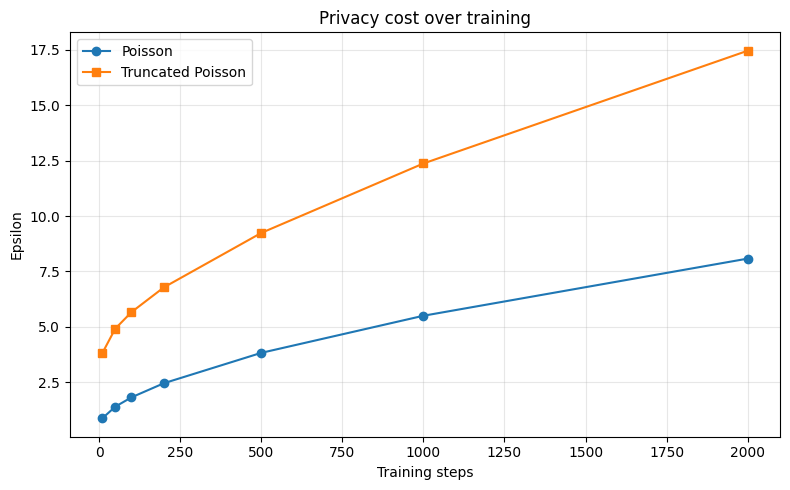

In [3]:
noise_mult = 1.1
sample_rate = 0.032
dataset_size = 1000
batch_cap = 40
delta = 1e-5

steps_range = [10, 50, 100, 200, 500, 1000, 2000]
eps_poisson = []
eps_truncated = []

for n in steps_range:
    p = dpsgd_acc.poisson(dpsgd_acc.gaussian(noise_mult), sample_rate) * n
    eps_poisson.append(p.epsilon_at(delta))

    t = (
        dpsgd_acc.poisson(
            dpsgd_acc.gaussian(noise_mult),
            sample_rate,
            truncated_batch_size=batch_cap,
            dataset_size=dataset_size,
        )
        * n
    )
    eps_truncated.append(t.epsilon_at(delta))

plt.figure(figsize=(8, 5))
plt.plot(steps_range, eps_poisson, "o-", label="Poisson")
plt.plot(steps_range, eps_truncated, "s-", label="Truncated Poisson")
plt.xlabel("Training steps")
plt.ylabel("Epsilon")
plt.title("Privacy cost over training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Calibrating the noise multiplier

`acc.calibrate` binary-searches for the noise multiplier that achieves
a target privacy budget over the full training run.

In [4]:
target_epsilon = 3.0
target_delta = 1e-5
sample_rate = 0.032
total_steps = 500

result = acc.calibrate(
    acc.epsilon_budget(target_epsilon, delta=target_delta),
    lambda nm: dpsgd_acc.poisson(dpsgd_acc.gaussian(nm), sample_rate) * total_steps,
    param_min=0.1,
    param_max=100.0,
)

print(f"Noise multiplier: {result.param:.4f}")

# Verify
check = dpsgd_acc.poisson(dpsgd_acc.gaussian(result.param), sample_rate) * total_steps
print(f"Achieved epsilon:  {check.epsilon_at(target_delta):.4f}")

Noise multiplier: 1.2655
Achieved epsilon:  3.0000


## Calibrating for different targets

`acc.calibrate` accepts different budget types. Here we compare the
noise multiplier required for several epsilon targets.

epsilon=  1.0  =>  noise_multiplier=2.8310


epsilon=  3.0  =>  noise_multiplier=1.2655


epsilon=  5.0  =>  noise_multiplier=0.9605


epsilon=  8.0  =>  noise_multiplier=0.7796


epsilon= 10.0  =>  noise_multiplier=0.7127


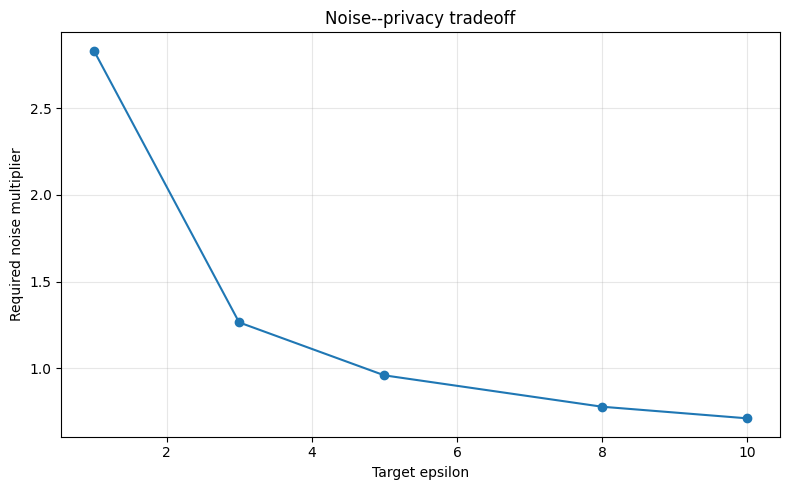

In [5]:
targets = [1.0, 3.0, 5.0, 8.0, 10.0]
multipliers = []

for eps_target in targets:
    r = acc.calibrate(
        acc.epsilon_budget(eps_target, delta=1e-5),
        lambda nm: dpsgd_acc.poisson(dpsgd_acc.gaussian(nm), 0.032) * 500,
        param_min=0.1,
        param_max=100.0,
    )
    multipliers.append(r.param)
    print(f"epsilon={eps_target:5.1f}  =>  noise_multiplier={r.param:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(targets, multipliers, "o-")
plt.xlabel("Target epsilon")
plt.ylabel("Required noise multiplier")
plt.title("Noise--privacy tradeoff")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Privacy metrics

A `DpProcess` supports several ways to query the privacy guarantee.

In [6]:
process = dpsgd_acc.poisson(dpsgd_acc.gaussian(1.0), sample_rate=0.01) * 1000

print(f"epsilon at delta=1e-5:  {process.epsilon_at(1e-5):.4f}")
print(f"delta at epsilon=1.0:   {process.delta_at(1.0):.2e}")
print(f"advantage:              {process.advantage():.4f}")

epsilon at delta=1e-5:  1.8282
delta at epsilon=1.0:   2.61e-03
advantage:              0.1610


## Heterogeneous composition

When different training phases use different noise levels, compose them
with the `|` operator.

In [7]:
# Phase 1: high noise (warm-up)
phase1 = dpsgd_acc.poisson(dpsgd_acc.gaussian(2.0), sample_rate=0.01) * 100

# Phase 2: lower noise (main training)
phase2 = dpsgd_acc.poisson(dpsgd_acc.gaussian(0.8), sample_rate=0.01) * 500

# Total cost
total = phase1 | phase2

print(f"Phase 1 alone:  epsilon={phase1.epsilon_at(1e-5):.4f}")
print(f"Phase 2 alone:  epsilon={phase2.epsilon_at(1e-5):.4f}")
print(f"Combined:       epsilon={total.epsilon_at(1e-5):.4f}")

Phase 1 alone:  epsilon=0.1898


Phase 2 alone:  epsilon=2.3994
Combined:       epsilon=2.4073


## Step-by-step tracking with Accountant

The `Accountant` class provides per-step tracking with optional budget
checking, useful inside training loops.

In [8]:
from opaque.accounting import Accountant

budget = acc.epsilon_budget(3.0, delta=1e-5)
accountant = Accountant(budget=budget)
step = dpsgd_acc.poisson(dpsgd_acc.gaussian(1.5), sample_rate=0.01)

for i in range(200):
    accountant = accountant | step
    if accountant.budget_exceeded:
        print(f"Budget exceeded at step {i + 1}")
        break

eps = accountant.epsilon_at(1e-5)
print(f"Final epsilon: {eps:.4f}")
print(f"Budget exceeded: {accountant.budget_exceeded}")

Final epsilon: 0.4062
Budget exceeded: False


## Summary

| Operation | Code |
|-----------|------|
| Gaussian mechanism | `dpsgd_acc.gaussian(noise_multiplier)` |
| Poisson sampling | `dpsgd_acc.poisson(mechanism, sample_rate)` |
| Truncated Poisson | `dpsgd_acc.poisson(mechanism, sample_rate, truncated_batch_size=..., dataset_size=...)` |
| Repeat | `process * n_steps` |
| Compose | `process_a \| process_b` |
| Query epsilon | `process.epsilon_at(delta)` |
| Calibrate | `acc.calibrate(acc.epsilon_budget(...), process=..., param_min=..., param_max=...)` |
| Budget tracking | `Accountant(budget=...) \| step` |

For a deeper discussion of the underlying theory, see
[Accounting](../user-guide/accounting.md) in the user guide.